In [1]:
### Import all necessary packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer

### Data Preprocessing

In [2]:
### Load the Dataset
df=pd.read_csv('anime.csv')

In [3]:
### Data Size
df.shape

(12294, 7)

In [4]:
### Data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   anime_id  12294 non-null  int64  
 1   name      12294 non-null  object 
 2   genre     12232 non-null  object 
 3   type      12269 non-null  object 
 4   episodes  12294 non-null  object 
 5   rating    12064 non-null  float64
 6   members   12294 non-null  int64  
dtypes: float64(1), int64(2), object(4)
memory usage: 672.5+ KB


In [5]:
### First five rows of data 
df.head()

,anime_id,name,genre,type,episodes,rating,members
0,32281,Kimi no Na wa.,"Drama, Romance, School, Supernatural",Movie,1,9.37,200630
1,5114,Fullmetal Alchemist: Brotherhood,"Action, Adventure, Drama, Fantasy, Magic, Mili...",TV,64,9.26,793665
2,28977,Gintama°,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.25,114262
3,9253,Steins;Gate,"Sci-Fi, Thriller",TV,24,9.17,673572
4,9969,Gintama&#039;,"Action, Comedy, Historical, Parody, Samurai, S...",TV,51,9.16,151266


In [6]:
### Check Duplicates
df.duplicated().sum()

np.int64(0)

     No Duplicates

In [7]:
### Check Missing Values
df.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [8]:
# Fill missing genres
df['genre'] = df['genre'].fillna('Unknown')

# Fill missing type
df['type'] = df['type'].fillna(df['type'].mode()[0])

# Fill missing ratings
df['rating'] = df['rating'].fillna(df['rating'].median())


* Genre → "Unknown" because it is a categorical feature and we don't know the actual genre.
* Type → Mode because it is a categorical column, and the most common type is a reasonable replacement.
* Rating → Median because it is a numerical feature and the median is less affected by extreme values than the mean.

In [9]:
### After Filling missing values
### Check Missing Values
df.isnull().sum()

anime_id    0
name        0
genre       0
type        0
episodes    0
rating      0
members     0
dtype: int64

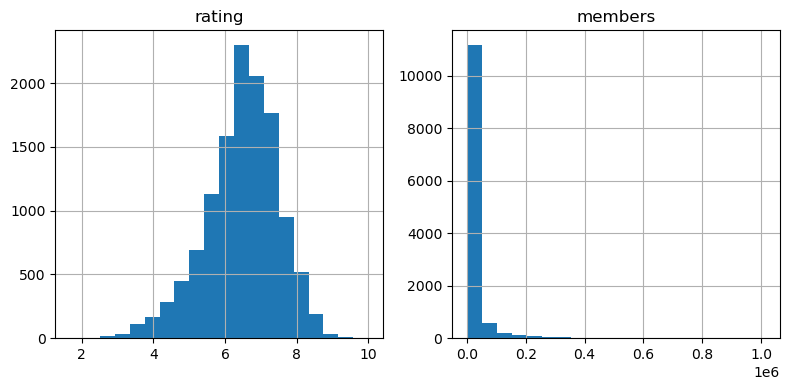

In [10]:
df[['rating', 'members']].hist(figsize=(8,4), bins=20)
plt.tight_layout()
plt.show()

**Rating Histogram**

* Most anime ratings are between 6 and 7.5.
* The ratings follow an approximately bell-shaped (normal) distribution.
* Very few anime have extremely low or extremely high ratings.

**Members Histogram**

* Most anime have a small number of members.
* A few anime have a very large number of members, creating a right-skewed distribution.
* This indicates the presence of outliers in the members column.

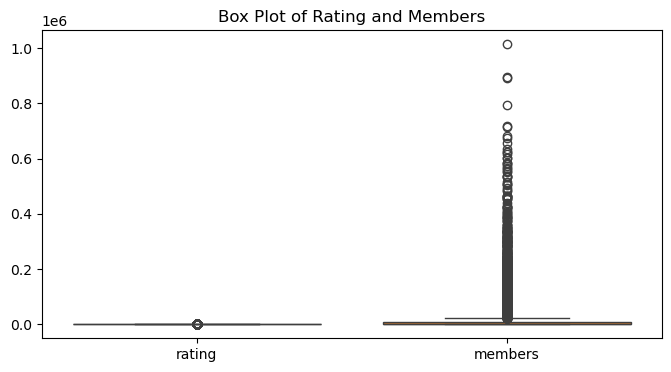

In [11]:
### Outlier check
plt.figure(figsize=(8,4))
sns.boxplot(data=df[['rating', 'members']])
plt.title("Box Plot of Rating and Members")
plt.show()

In [12]:
### Outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)

cols=['rating', 'members']
for col in cols:
    outlier_capping(df,col)

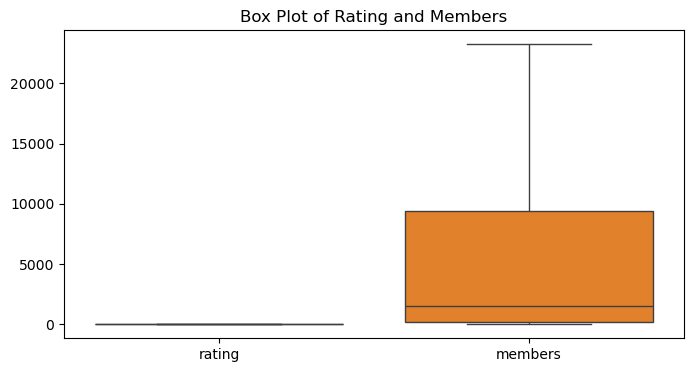

In [13]:
#### After capping
### Outlier check
plt.figure(figsize=(8,4))
sns.boxplot(data=df[['rating', 'members']])
plt.title("Box Plot of Rating and Members")
plt.show()

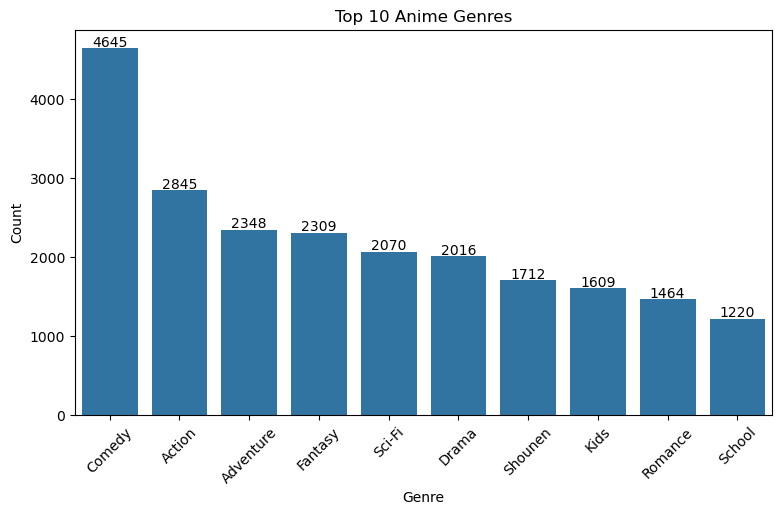

In [14]:
genre_counts = df['genre'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(9,5))

ax = sns.barplot(x=genre_counts.index, y=genre_counts.values)

# Add count labels
for i, v in enumerate(genre_counts.values):
    ax.text(i, v + 20, str(v), ha='center', fontsize=10)

plt.xticks(rotation=45)
plt.title("Top 10 Anime Genres")
plt.xlabel("Genre")
plt.ylabel("Count")

plt.show()

* Comedy is the most common genre with 4,645 anime.
* Action is the second most common genre with 2,845 anime.
* Adventure (2,348) and Fantasy (2,309) are also popular genres.
* Sci-Fi (2,070) and Drama (2,016) appear frequently in the dataset.
* School is the least common genre among the top 10, with 1,220 anime.
* The dataset contains a wide variety of genres, which helps improve the recommendation system by providing meaningful genre-based similarity.

### Feature Extraction

In [15]:
tfidf=TfidfVectorizer(stop_words='english')

In [16]:
import nltk
from nltk.corpus import stopwords
print(stopwords.words('english'))

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [17]:
len(stopwords.words('english'))

198

In [18]:
tfidf1=tfidf.fit_transform(df.genre)

In [19]:
tfidf1

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 40480 stored elements and shape (12294, 47)>

In [20]:
similarities=cosine_similarity(tfidf1,tfidf1)
similarities.shape

(12294, 12294)

In [21]:
indices= pd.Series(data=df.index,index=df.name)
indices

name
Kimi no Na wa.                                            0
Fullmetal Alchemist: Brotherhood                          1
Gintama°                                                  2
Steins;Gate                                               3
Gintama&#039;                                             4
                                                      ...  
Toushindai My Lover: Minami tai Mecha-Minami          12289
Under World                                           12290
Violence Gekiga David no Hoshi                        12291
Violence Gekiga Shin David no Hoshi: Inma Densetsu    12292
Yasuji no Pornorama: Yacchimae!!                      12293
Length: 12294, dtype: int64

### Recommendation System

In [22]:
def recommended_anime(similar_anime):
    if similar_anime in indices.index:
        index= np.where(similar_anime==indices.index)[0][0]
        similar=sorted(list(enumerate(similarities[index])),reverse=True,key=lambda x: x[1])[1:6]
        print(f'Recommended anime of {similar_anime}')
        print('*'*30)
        for anime in similar:
            print(indices.index[anime[0]])
    else:
        print('Anime is not in the list')

In [23]:
recommended_anime('Steins;Gate')

Recommended anime of Steins;Gate
******************************
Steins;Gate Movie: Fuka Ryouiki no Déjà vu
Steins;Gate: Oukoubakko no Poriomania
Steins;Gate: Kyoukaimenjou no Missing Link - Divide By Zero
Steins;Gate 0
Under the Dog


* The recommendation system successfully recommended anime similar to Steins;Gate.
* Most of the recommended anime belong to the Steins;Gate series, indicating that the model correctly identified highly similar content.
* Under the Dog was also recommended because it shares similar themes or genres with Steins;Gate.
* The recommendations were generated using TF-IDF Vectorization and the cosine similarity, which measured the similarity between anime based on their content.
* Overall, the recommendation system provides relevant and meaningful anime suggestions.

In [30]:
#### using with different thrershold to find top 5 animes
def recommended_anime(similar_anime, threshold=0.3):
    if similar_anime in indices.index:
        index = indices[similar_anime]

        sim_scores = list(enumerate(similarities[index]))

        sim_scores = [x for x in sim_scores if x[1] >= threshold]

        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:]

        print(f"Recommended anime for {similar_anime}")
        print("*" * 30)

        for anime in sim_scores[:5]:
            print(indices.index[anime[0]], ":", round(anime[1], 3))
    else:
        print("Anime is not in the list")

In [27]:
recommended_anime("Kimi no Na wa.", threshold=0.2)

Recommended anime for Kimi no Na wa.
******************************
Wind: A Breath of Heart OVA : 1.0
Wind: A Breath of Heart (TV) : 1.0
Aura: Maryuuin Kouga Saigo no Tatakai : 0.955
Angel Beats!: Another Epilogue : 0.872
Harmonie : 0.872


* The recommendation system successfully suggested anime similar to Kimi no Na wa.
* The top recommendations have high cosine similarity scores, indicating strong genre similarity.
* Overall, the system provides relevant recommendations using TF-IDF and Cosine Similarity.

In [31]:
recommended_anime("Gintama°", threshold=0.6)

Recommended anime for Gintama°
******************************
Gintama&#039; : 1.0
Gintama Movie: Kanketsu-hen - Yorozuya yo Eien Nare : 1.0
Gintama&#039;: Enchousen : 1.0
Gintama : 1.0
Gintama: Yorinuki Gintama-san on Theater 2D : 1.0


* The recommendation system successfully recommended anime similar to Gintama°.
* Most of the recommended anime belong to the Gintama series.
* These anime received a cosine similarity score of 1.0 because they have identical or nearly identical genre information.
* Using a threshold of 0.6 returned only highly similar anime, resulting in relevant recommendations.

**Performance Analysis**
* The recommendation system successfully generated similar anime recommendations.
* TF-IDF and cosine similarity effectively identified anime with similar genres.
* The recommendations were relevant for the selected anime.

**Areas of Improvement**
* Include user ratings to provide personalized recommendations.
* Use additional features such as type, episodes, and members.
* Combine content-based and collaborative filtering for better recommendation quality.
* Use advanced techniques such as Word2Vec, BERT, or Sentence Transformers to improve similarity measurement.

### Interview Questions

##### 1. Can you explain the difference between user-based and item-based collaborative filtering?

**User-Based Collaborative Filtering**
* Recommends items based on similar users.
* Finds users with similar preferences.
* Suggests items liked by those similar users.
  
**Item-Based Collaborative Filtering**
* Recommends items similar to those the user already likes.
* Finds similarities between items instead of users.
* Suggests items with similar characteristics or user ratings.

##### 2. What is collaborative filtering, and how does it work?

Collaborative filtering is a recommendation technique that suggests items based on the preferences and behavior of users.

**How it works**
* Collects user ratings or interactions.
* Finds similarities between users or items.
* Predicts items a user may like.
* Recommends the most relevant items based on similarity.